In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# import geopandas as gpd

# blocks = gpd.read_file("../data/blocks_clean.geojson")
# blocks.head()

In [3]:
blocks = gpd.read_parquet('../data/traning_data/blocks_with_land_value_class.parquet')
blocks["land_use"] = blocks["land_use"].replace(
    [None, "None", "none", "NaN", "nan", "NULL", "null", ""],
    pd.NA
)
blocks = blocks[blocks["land_use"].notna()].copy()


blocks.head()

,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,area_accessibility,land_value_per_sqm,log_land_value,log_land_value_per_sqm,land_value_class_soft_0,land_value_class_soft_1,land_value_class_soft_2,land_value_class_soft_3,land_value_class_pred,land_value_class_soft_expected
0,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.000000,0.401072,0.0,0.417018,AGRICULTURE,0.417018,...,113.847998,942.386203,18.676889,6.849476,0.141792,0.440618,0.350797,0.066793,1,1.342591
1,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,1.000000,...,145.884534,1952.414484,19.040968,7.577334,0.012638,0.107291,0.826455,0.053615,2,1.921047
2,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,0.729125,...,148.543184,1507.223306,19.061421,7.318688,0.023362,0.107805,0.776600,0.092233,2,1.937704
3,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.000000,0.144935,0.0,0.399984,RESIDENTIAL,0.454375,...,132.691062,2197.747147,19.737919,7.695643,0.010342,0.200107,0.548507,0.241044,2,2.020252
4,"POLYGON ((347215.933 6646341.789, 347245.429 6...",0.108707,0.0,0.000000,0.767131,0.057528,0.0,0.000000,INDUSTRIAL,0.767131,...,99.160727,8603.688296,17.843517,9.060062,0.512695,0.456094,0.029580,0.001631,0,0.520147


In [4]:
blocks_with_large_errors = gpd.read_file("../data/traning_data/blocks_with_large_errors.geojson")
blocks_with_error_over_60pct = gpd.read_file("../data/traning_data/blocks_with_error_over_60pct.geojson")
blocks_with_error_over_60pct2 = gpd.read_file("../data/traning_data/blocks_with_error_over_60pct2.geojson")
blocks_with_error_over_60pct3 = gpd.read_file("../data/traning_data/blocks_with_error_over_60pct3.geojson")
blocks_with_error_over_60pct3.head()   

,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,n_neighbors_300,n_neighbors_500,n_neighbors_1000,n_neighbors_2000,n_neighbors_3000,pred_raw,land_value_pred,land_value_true,error_pct,geometry
0,0.108342,0.000000,0.891658,0.0,0.000000,0.0,0.0,RECREATION,0.891658,0.000000,...,5,14,60,205,447,5.678058e+07,5.678058e+07,1.786907e+07,217.758932,"POLYGON ((351428.245 6647300.266, 351440.055 6..."
1,0.024715,0.072627,0.489266,0.0,0.413393,0.0,0.0,RECREATION,0.489266,161.467098,...,10,21,74,248,427,6.659308e+06,6.659308e+06,2.074318e+07,67.896405,"POLYGON ((348997.996 6646368.274, 348999.869 6..."
2,0.226151,0.590566,0.132126,0.0,0.051156,0.0,0.0,BUSINESS,0.590566,32311.556107,...,4,10,43,181,434,5.592216e+08,5.592216e+08,3.421804e+08,63.428892,"POLYGON ((351482.192 6648261.957, 351499.765 6..."
3,0.999419,0.000581,0.000000,0.0,0.000000,0.0,0.0,RESIDENTIAL,0.999419,8227.586617,...,3,9,33,82,185,2.868954e+08,2.868954e+08,1.712276e+08,67.552047,"POLYGON ((347126.83 6643214.39, 347135.632 664..."
4,0.763586,0.000000,0.000000,0.0,0.236414,0.0,0.0,RESIDENTIAL,0.763586,4099.369141,...,4,15,52,154,291,1.421954e+08,1.421954e+08,8.546343e+07,66.381611,"POLYGON ((353573.678 6646818.066, 353573.235 6..."


In [5]:
# старт
blocks_clean = blocks.copy()

# 1) удалить blocks_with_large_errors
tmp = blocks_with_large_errors
if blocks_clean.crs != tmp.crs:
    tmp = tmp.to_crs(blocks_clean.crs)
bad_geom = set(tmp.geometry.to_wkb())
blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

# 2) удалить blocks_with_error_over_60pct
tmp = blocks_with_error_over_60pct
if blocks_clean.crs != tmp.crs:
    tmp = tmp.to_crs(blocks_clean.crs)
bad_geom = set(tmp.geometry.to_wkb())
blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

# # # 3) удалить blocks_with_error_over_60pct2
# tmp = blocks_with_error_over_60pct2
# if blocks_clean.crs != tmp.crs:
#     tmp = tmp.to_crs(blocks_clean.crs)
# bad_geom = set(tmp.geometry.to_wkb())
# blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

# # 4) удалить blocks_with_error_over_60pct3
# tmp = blocks_with_error_over_60pct3
# if blocks_clean.crs != tmp.crs:
#     tmp = tmp.to_crs(blocks_clean.crs)
# bad_geom = set(tmp.geometry.to_wkb())
# blocks_clean = blocks_clean.loc[~blocks_clean.geometry.to_wkb().isin(bad_geom)].copy()

blocks_clean.head()



,geometry,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,...,area_accessibility,land_value_per_sqm,log_land_value,log_land_value_per_sqm,land_value_class_soft_0,land_value_class_soft_1,land_value_class_soft_2,land_value_class_soft_3,land_value_class_pred,land_value_class_soft_expected
0,"POLYGON ((352083.617 6633950.146, 352240.448 6...",0.099000,0.0,0.079912,0.000000,0.401072,0.0,0.417018,AGRICULTURE,0.417018,...,113.847998,942.386203,18.676889,6.849476,0.141792,0.440618,0.350797,0.066793,1,1.342591
1,"POLYGON ((346700.642 6618453.176, 346681.107 6...",1.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,1.000000,...,145.884534,1952.414484,19.040968,7.577334,0.012638,0.107291,0.826455,0.053615,2,1.921047
2,"POLYGON ((347043.363 6618261.219, 347042.608 6...",0.729125,0.0,0.270875,0.000000,0.000000,0.0,0.000000,RESIDENTIAL,0.729125,...,148.543184,1507.223306,19.061421,7.318688,0.023362,0.107805,0.776600,0.092233,2,1.937704
3,"POLYGON ((354879.039 6618859.116, 354845.405 6...",0.454375,0.0,0.000000,0.000000,0.144935,0.0,0.399984,RESIDENTIAL,0.454375,...,132.691062,2197.747147,19.737919,7.695643,0.010342,0.200107,0.548507,0.241044,2,2.020252
4,"POLYGON ((347215.933 6646341.789, 347245.429 6...",0.108707,0.0,0.000000,0.767131,0.057528,0.0,0.000000,INDUSTRIAL,0.767131,...,99.160727,8603.688296,17.843517,9.060062,0.512695,0.456094,0.029580,0.001631,0,0.520147


In [6]:
# blocks_clean.to_parquet('../data/traning_data/blocks_clean_for_model_training.parquet', index=False)

In [7]:
# import matplotlib.pyplot as plt

# fig, ax = plt.subplots(figsize=(15, 15))

# # Все кварталы серым фоном
# blocks.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.2)

# # Отфильтрованные поверх с раскраской по land_value_per_sqm
# blocks_clean.plot(
#     ax=ax,
#     column="land_value",
#     cmap="viridis",
#     legend=True,
#     edgecolor="black",
#     linewidth=0.2
# )

# ax.axis("off")
# plt.show()

In [8]:
import pandas as pd

col = "land_use"

# Кол-во по land_use в blocks
cnt_blocks = (
    blocks[col]
    .value_counts(dropna=False)
    .rename("count_blocks")
)

# Кол-во по land_use в blocks_clean
cnt_blocks_clean = (
    blocks_clean[col]
    .value_counts(dropna=False)
    .rename("count_blocks_clean")
)

# Объединяем в одну таблицу
land_use_counts = (
    pd.concat([cnt_blocks, cnt_blocks_clean], axis=1)
    .fillna(0)
    .astype(int)
    .reset_index()
    .rename(columns={"index": col})
    .sort_values(col, na_position="last")
)

display(land_use_counts)


,land_use,count_blocks,count_blocks_clean
5,AGRICULTURE,142,119
4,BUSINESS,309,270
3,INDUSTRIAL,501,447
1,RECREATION,1671,1065
0,RESIDENTIAL,4919,4207
6,SPECIAL,126,102
2,TRANSPORT,1049,807


In [9]:
# import osmnx as ox
# import geopandas as gpd

# # 1) Граница Санкт-Петербурга
# city = ox.geocode_to_gdf("Saint Petersburg, Russia")
# city_polygon = city.geometry.iloc[0]

# # 2) Загружаем административные границы уровня 5
# tags = {
#     "boundary": "administrative",
#     "admin_level": "5",
# }

# districts = ox.features_from_polygon(city_polygon, tags=tags).reset_index()

# # 3) Оставляем только полигональные геометрии
# districts = districts[districts.geometry.geom_type.isin(["Polygon", "MultiPolygon"])].copy()

# # 4) Полезные поля
# keep_cols = [
#     c for c in [
#         "name",
#         "name:ru",
#         "official_name",
#         "boundary",
#         "admin_level",
#         "wikidata",
#         "geometry",
#     ]
#     if c in districts.columns
# ]

# districts = districts[keep_cols].drop_duplicates().reset_index(drop=True)


# districts = districts[districts["admin_level"] == "5"].copy()
# districts = districts.iloc[:-1].copy()

# districts 



In [10]:
# districts.to_file("../data/traning_data/districts_spb.geojson", driver="GeoJSON")

In [11]:
districts = gpd.read_file('../data/traning_data/districts_spb.geojson')
districts

,name,name:ru,official_name,boundary,admin_level,wikidata,geometry
0,Колпинский район,Колпинский район,None,administrative,5,Q1326302,"POLYGON ((30.44112 59.82937, 30.44333 59.8298,..."
1,Пушкинский район,Пушкинский район,None,administrative,5,Q220316,"POLYGON ((30.21822 59.67307, 30.21918 59.67361..."
2,Московский район,Московский район,None,administrative,5,Q270112,"POLYGON ((30.19877 59.80161, 30.19901 59.8018,..."
3,Красносельский район,Красносельский район,None,administrative,5,Q270124,"MULTIPOLYGON (((30.06517 59.67798, 30.07283 59..."
4,Петродворцовый район,Петродворцовый район,None,administrative,5,Q270114,"MULTIPOLYGON (((30.04464 59.8635, 30.04455 59...."
5,Невский район,Невский район,None,administrative,5,Q1193156,"POLYGON ((30.36331 59.91387, 30.36951 59.91412..."
6,Фрунзенский район,Фрунзенский район,None,administrative,5,Q1142777,"POLYGON ((30.33258 59.91305, 30.33352 59.91337..."
7,Адмиралтейский район,Адмиралтейский район,None,administrative,5,Q219746,"POLYGON ((30.25023 59.90129, 30.25028 59.90132..."
8,Василеостровский район,Василеостровский район,None,administrative,5,Q220622,"POLYGON ((30.18468 59.95472, 30.18473 59.95481..."
9,Выборгский район,Выборгский район,None,administrative,5,Q219907,"POLYGON ((30.0729 60.09727, 30.08512 60.10426,..."


In [12]:
import geopandas as gpd

# districts — GeoDataFrame с полигонами районов из OSM
# blocks_clean — GeoDataFrame с кварталами

# 1) Выбираем колонку с названием района
district_name_col = "name:ru" if "name:ru" in districts.columns else "name"

districts_for_join = districts[[district_name_col, "geometry"]].copy()
districts_for_join = districts_for_join.rename(columns={district_name_col: "district_name"})

# 2) Приводим CRS
districts_for_join = districts_for_join.to_crs(blocks_clean.crs)

# 3) Для кварталов берём внутреннюю точку, чтобы не было дублей на границах
blocks_points = blocks_clean.copy()
blocks_points["geometry"] = blocks_points.geometry.representative_point()

# 4) Spatial join
joined = gpd.sjoin(
    blocks_points[["geometry"]],
    districts_for_join,
    how="left",
    predicate="within",
)

# 5) Добавляем атрибут района обратно в blocks_clean
blocks_clean = blocks_clean.copy()
blocks_clean["district_name"] = joined["district_name"]

# 6) Проверка
display(blocks_clean[["district_name", "geometry"]].head())
print("Missing district_name:", blocks_clean["district_name"].isna().sum())


,district_name,geometry
0,Московский район,"POLYGON ((352083.617 6633950.146, 352240.448 6..."
1,Пушкинский район,"POLYGON ((346700.642 6618453.176, 346681.107 6..."
2,Пушкинский район,"POLYGON ((347043.363 6618261.219, 347042.608 6..."
3,Пушкинский район,"POLYGON ((354879.039 6618859.116, 354845.405 6..."
4,Василеостровский район,"POLYGON ((347215.933 6646341.789, 347245.429 6..."


Missing district_name: 0


In [13]:
# districts = [
#     "Московский район",
#     "Калининский район",
#     "Василеостровский район",
#     "Петроградский район",
#     "Центральный район",
#     'Фрунзенский район',
# ]

# blocks_clean = blocks_clean[
#     blocks_clean["district_name"].isin(districts)
# ].copy()


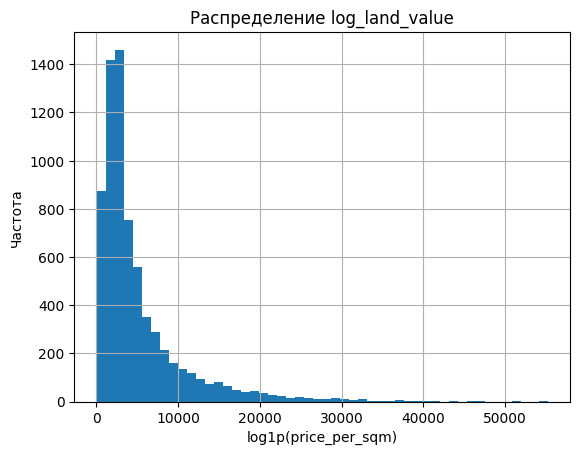

In [14]:

# Гистограмма
plt.figure()
blocks_clean['land_value_per_sqm'].hist(bins=50)
plt.xlabel('log1p(price_per_sqm)')
plt.ylabel('Частота')
plt.title('Распределение log_land_value')
plt.show()

land_value_per_sqm                1.000000
log_land_value_per_sqm            0.843005
fsi                               0.710287
gsi                               0.622850
l                                 0.494540
log_land_value                    0.425248
share_non_living                  0.412218
share_living                      0.408648
land_value                        0.366499
land_value_class_soft_expected    0.346658
land_value_class_pred             0.344383
land_value_class_soft_3           0.329302
residential                       0.329191
living_area                       0.260507
build_floor_area                  0.252271
population                        0.205612
mxi                               0.202862
non_living_area                   0.191255
footprint_area                    0.114192
land_value_class_soft_2           0.036216
business                          0.004275
share                            -0.036181
osr                              -0.042672
special    

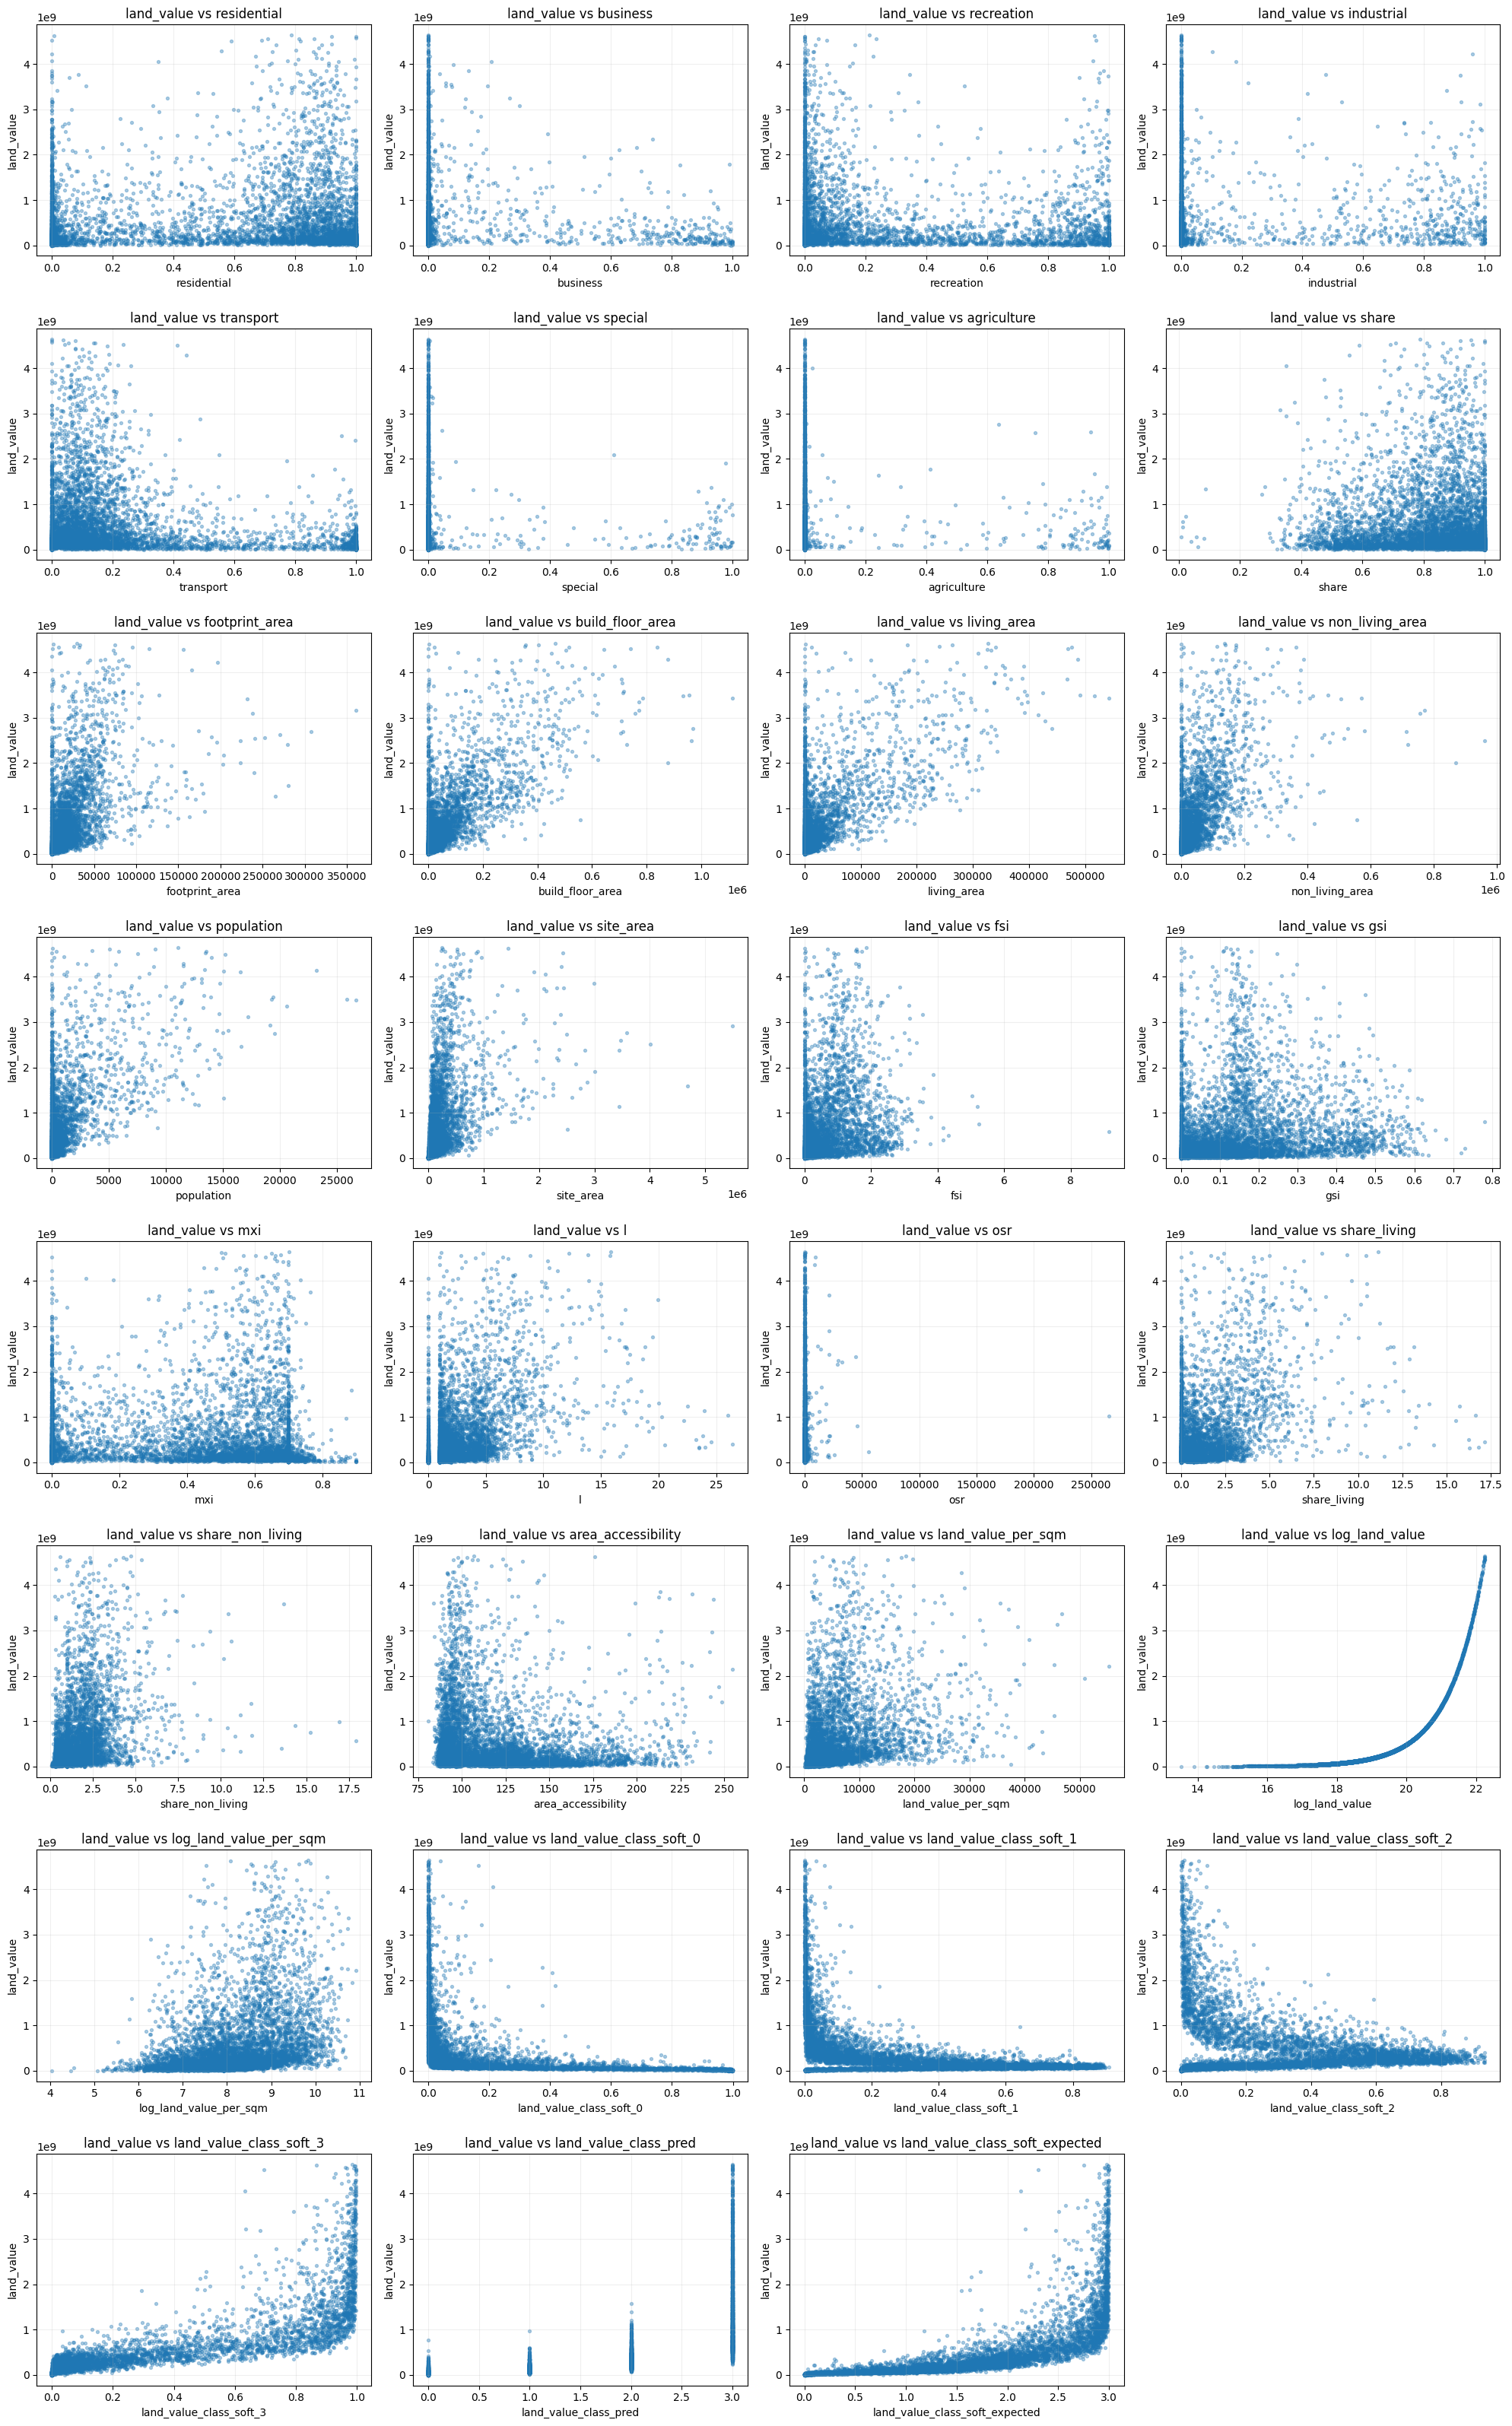

In [17]:
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

target_col = "land_value_per_sqm"
num_cols = [c for c in blocks_clean.columns if pd.api.types.is_numeric_dtype(blocks_clean[c])]
corr_to_target = (
    blocks_clean[num_cols]
    .corr(method="pearson")[target_col]
    .dropna()
    .sort_values(ascending=False)
)
display(corr_to_target)

# Целевая переменная
target_col = "land_value"

# Берем все фичи кроме target и geometry
exclude = {target_col, "geometry"}
feature_cols = [c for c in blocks_clean.columns if c not in exclude]

# Числовые фичи для scatter
num_features = [
    c for c in feature_cols
    if pd.api.types.is_numeric_dtype(blocks_clean[c])
]

# Подготовка
n = len(num_features)
ncols = 4
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)
axes = axes.flatten()

for i, col in enumerate(num_features):
    tmp = blocks_clean[[col, target_col]].dropna()
    axes[i].scatter(tmp[col], tmp[target_col], s=8, alpha=0.35)
    axes[i].set_title(f"{target_col} vs {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(target_col)
    axes[i].grid(alpha=0.2)

# Удаляем пустые оси
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [16]:
q = blocks_clean["land_value"].quantile(0.99)
blocks_clean = blocks_clean[blocks_clean["land_value"] < q].copy()

In [16]:
# q = blocks_clean["land_value_per_sqm"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["land_value_per_sqm"] < q].copy()
# q = blocks_clean["footprint_area"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["footprint_area"] < q].copy()
# q = blocks_clean["land_value"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["land_value"] < q].copy()
# q = blocks_clean["osr"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["osr"] < q].copy()
# q = blocks_clean["fsi"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["fsi"] < q].copy()
# q = blocks_clean["site_area"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["site_area"] < q].copy()
# q = blocks_clean["living_area"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["living_area"] < q].copy()
# q = blocks_clean["non_living_area"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["non_living_area"] < q].copy()
# q = blocks_clean["share_living"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["share_living"] < q].copy()
# q = blocks_clean["share_non_living"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["share_non_living"] < q].copy()
# q = blocks_clean["population"].quantile(0.99)
# blocks_clean = blocks_clean[blocks_clean["population"] < q].copy()

In [17]:
# q = blocks_clean["land_value_per_sqm"].quantile(0.01)
# blocks_clean = blocks_clean[blocks_clean["land_value_per_sqm"] > q].copy()


# XGBoost

In [18]:
# # === Simple train/test training with XGBoost (без фолдов) ===
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# import numpy as np
# import pandas as pd
# from xgboost import XGBRegressor

# from urbanomy.methods.land_value_modeling.training_utils import (
#     build_radii_weights,
#     add_lags_full_df,
#     feature_names,
#     to_original_scale,
#     mape,
#     wape,
# )

# # 1) Настройки
# target_col = "log_land_value_per_sqm"
# radius_list = [300, 500, 1000, 2000, 3000]
# test_size = 0.2
# seed = 42
# use_services = False

# exclude_base = {
#     "geometry",
#     "land_value",
#     "land_value_per_sqm",
#     "log_land_value_per_sqm",
#     "log_land_value",
#     "osr",
#     "share_non_living",
#     "share_living",
#     "land_value_class_soft_expected",
#     "district_name",
# }

# cat_features = [c for c in ["land_use", "morphotype"] if c in blocks_clean.columns]

# def is_service_col(col: str) -> bool:
#     return col.lower().startswith("count_")

# # 2) Базовые признаки
# feature_cols = []
# for c in blocks_clean.columns:
#     if c in exclude_base:
#         continue
#     if (not use_services) and is_service_col(c):
#         continue
#     feature_cols.append(c)

# # 3) Подготовка данных + lag-фичи на всем датасете
# data_df = blocks_clean.copy()

# for c in cat_features:
#     data_df[c] = data_df[c].astype("string").fillna("missing")

# numeric_feats = [
#     c for c in feature_cols
#     if c not in cat_features and c != target_col and c in data_df.columns
# ]

# weights = build_radii_weights(data_df, radius_list)
# data_lag = add_lags_full_df(data_df, weights=weights, numeric_cols=numeric_feats)

# base_cols_for_model = list(dict.fromkeys(
#     [c for c in feature_cols if c in data_lag.columns] + cat_features
# ))
# feats = feature_names(data_lag, base_cols_for_model, target_col)

# # 4) Train/test split
# idx_train, idx_test = train_test_split(
#     data_lag.index,
#     test_size=test_size,
#     random_state=seed,
#     shuffle=True,
# )

# df_train = data_lag.loc[idx_train].copy()
# df_test = data_lag.loc[idx_test].copy()

# # 5) Подготовка X / y
# X_train = df_train[feats].copy()
# X_test = df_test[feats].copy()

# # one-hot encoding для категориальных признаков
# cat_feats_for_ohe = [c for c in cat_features if c in X_train.columns]

# X_train = pd.get_dummies(X_train, columns=cat_feats_for_ohe, dummy_na=False)
# X_test = pd.get_dummies(X_test, columns=cat_feats_for_ohe, dummy_na=False)

# # выравниваем набор колонок между train и test
# X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)
# X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# y_train = df_train[target_col].to_numpy()
# y_test = df_test[target_col].to_numpy()

# # 6) Обучение
# model = XGBRegressor(
#     objective="reg:squarederror",
#     eval_metric="rmse",
#     n_estimators=40000,
#     learning_rate=0.03,
#     max_depth=6,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=seed,
#     n_jobs=-1,
#     early_stopping_rounds=1000,
# )

# model.fit(
#     X_train,
#     y_train,
#     eval_set=[(X_test, y_test)],
#     verbose=200,
# )

# # 7) Метрики на train и test в оригинальной шкале
# # --- Train ---
# y_train_pred_raw = np.asarray(model.predict(X_train)).reshape(-1)
# y_train_true_raw = y_train

# y_train_true = to_original_scale(y_train_true_raw, target_col=target_col)
# y_train_pred = to_original_scale(y_train_pred_raw, target_col=target_col)

# train_mape = mape(y_train_true, y_train_pred)
# train_wape = wape(y_train_true, y_train_pred)
# train_r2 = r2_score(y_train_true, y_train_pred)
# train_mae = mean_absolute_error(y_train_true, y_train_pred)
# train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

# # --- Test ---
# y_test_pred_raw = np.asarray(model.predict(X_test)).reshape(-1)
# y_test_true_raw = y_test

# y_test_true = to_original_scale(y_test_true_raw, target_col=target_col)
# y_test_pred = to_original_scale(y_test_pred_raw, target_col=target_col)

# test_mape = mape(y_test_true, y_test_pred)
# test_wape = wape(y_test_true, y_test_pred)
# test_r2 = r2_score(y_test_true, y_test_pred)
# test_mae = mean_absolute_error(y_test_true, y_test_pred)
# test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))

# print("Train metrics:")
# print(f"MAPE: {train_mape:.6f} ({train_mape*100:.2f}%)")
# print(f"WAPE: {train_wape:.6f} ({train_wape*100:.2f}%)")
# print(f"MAE:  {train_mae:.6f}")
# print(f"RMSE: {train_rmse:.6f}")
# print(f"R2:   {train_r2:.6f}")

# print("\nTest metrics:")
# print(f"MAPE: {test_mape:.6f} ({test_mape*100:.2f}%)")
# print(f"WAPE: {test_wape:.6f} ({test_wape*100:.2f}%)")
# print(f"MAE:  {test_mae:.6f}")
# print(f"RMSE: {test_rmse:.6f}")
# print(f"R2:   {test_r2:.6f}")


# CatBoost

In [ ]:
# === Simple train/test training (без фолдов) + дообучение на всем датасете ===
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
from catboost import CatBoostRegressor, Pool

from urbanomy.methods.land_value_modeling.training_utils import (
    build_radii_weights,
    add_lags_full_df,
    feature_names,
    to_original_scale,
    mape,
    wape,
)

# 1) Настройки
target_col = "log_land_value"
radius_list = [500, 1000, 2000, 3000]
test_size = 0.2
seed = 42
use_services = False

exclude_base = {
    "geometry",
    "land_value",
    "land_value_per_sqm",
    "log_land_value_per_sqm",
    "log_land_value",
    "osr",
    "share_non_living",
    "share_living",
    # "land_value_class_soft_0",
    # "land_value_class_soft_1",
    # "land_value_class_soft_2",
    # "land_value_class_soft_3",
    # "land_value_class_soft_4",
    # "land_value_class_pred",
    "land_value_class_soft_expected",
    "district_name",
    "number_of_floors",
}
cat_features = [c for c in ["land_use", "morphotype", 'land_value_class_pred'] if c in blocks_clean.columns]

def is_service_col(col: str) -> bool:
    return col.lower().startswith("count_")

# 2) Базовые признаки
feature_cols = []
for c in blocks_clean.columns:
    if c in exclude_base:
        continue
    if (not use_services) and is_service_col(c):
        continue
    feature_cols.append(c)

# 3) Подготовка данных + lag-фичи на всем датасете
data_df = blocks_clean.copy()
for c in cat_features:
    data_df[c] = data_df[c].astype("string").fillna("missing")

numeric_feats = [
    c for c in feature_cols
    if c not in cat_features and c != target_col and c in data_df.columns
]

weights = build_radii_weights(data_df, radius_list)
data_lag = add_lags_full_df(data_df, weights=weights, numeric_cols=numeric_feats)

base_cols_for_model = list(dict.fromkeys([c for c in feature_cols if c in data_lag.columns] + cat_features))
feats = feature_names(data_lag, base_cols_for_model, target_col)
cat_features_used = [c for c in cat_features if c in feats]

# 4) Один train/test split (без кросс-валидации)
idx_train, idx_test = train_test_split(
    data_lag.index,
    test_size=test_size,
    random_state=seed,
    shuffle=True,
)

df_train = data_lag.loc[idx_train].copy()
df_test = data_lag.loc[idx_test].copy()

train_pool = Pool(df_train[feats], label=df_train[target_col], cat_features=cat_features_used, feature_names=feats)
test_pool = Pool(df_test[feats], label=df_test[target_col], cat_features=cat_features_used, feature_names=feats)

# 5) Обучение и подбор лучшей длины бустинга на holdout
base_params = dict(
    loss_function="MAE",
    eval_metric="MAE",
    learning_rate=0.03,
    depth=8,
    subsample=0.8,
    rsm=0.8,
    random_seed=seed,
)

model_eval = CatBoostRegressor(
    **base_params,
    iterations=20000,
    od_type="Iter",
    od_wait=2000,
    verbose=200,
)

model_eval.fit(
    train_pool,
    eval_set=test_pool,
    early_stopping_rounds=600,
    use_best_model=True,
)

# 6) Метрики на train и test в оригинальной шкале
# --- Train ---
y_train_pred_raw = np.asarray(model_eval.predict(df_train[feats])).reshape(-1)
y_train_true_raw = df_train[target_col].to_numpy()

y_train_true = to_original_scale(y_train_true_raw, target_col=target_col)
y_train_pred = to_original_scale(y_train_pred_raw, target_col=target_col)

train_mape = mape(y_train_true, y_train_pred)
train_wape = wape(y_train_true, y_train_pred)
train_r2 = r2_score(y_train_true, y_train_pred)
train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

# --- Test ---
y_test_pred_raw = np.asarray(model_eval.predict(df_test[feats])).reshape(-1)
y_test_true_raw = df_test[target_col].to_numpy()

y_test_true = to_original_scale(y_test_true_raw, target_col=target_col)
y_test_pred = to_original_scale(y_test_pred_raw, target_col=target_col)

test_mape = mape(y_test_true, y_test_pred)
test_wape = wape(y_test_true, y_test_pred)
test_r2 = r2_score(y_test_true, y_test_pred)
test_mae = mean_absolute_error(y_test_true, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))

print("Train metrics:")
print(f"MAPE: {train_mape:.6f} ({train_mape*100:.2f}%)")
print(f"WAPE: {train_wape:.6f} ({train_wape*100:.2f}%)")
print(f"MAE:  {train_mae:.6f}")
print(f"RMSE: {train_rmse:.6f}")
print(f"R2:   {train_r2:.6f}")

print("\nTest metrics:")
print(f"MAPE: {test_mape:.6f} ({test_mape*100:.2f}%)")
print(f"WAPE: {test_wape:.6f} ({test_wape*100:.2f}%)")
print(f"MAE:  {test_mae:.6f}")
print(f"RMSE: {test_rmse:.6f}")
print(f"R2:   {test_r2:.6f}")

# 7) Финальное обучение на всем датасете после расчета метрик
# Берем оптимальное число итераций с holdout-модели
best_iter = model_eval.get_best_iteration()
final_iterations = int(best_iter + 1) if best_iter is not None and best_iter >= 0 else 20000

full_pool = Pool(
    data_lag[feats],
    label=data_lag[target_col],
    cat_features=cat_features_used,
    feature_names=feats,
)

model = CatBoostRegressor(
    **base_params,
    iterations=final_iterations,
    verbose=200,
)

model.fit(full_pool)

print(f"\nFinal model trained on full dataset with iterations={final_iterations}")


0:	learn: 1.0877945	test: 1.0905796	best: 1.0905796 (0)	total: 11.9ms	remaining: 3m 58s
200:	learn: 0.2528717	test: 0.2958773	best: 0.2958773 (200)	total: 2.96s	remaining: 4m 51s
400:	learn: 0.2031996	test: 0.2795471	best: 0.2795339 (399)	total: 6.37s	remaining: 5m 11s
600:	learn: 0.1700829	test: 0.2737030	best: 0.2737030 (600)	total: 10.3s	remaining: 5m 31s
800:	learn: 0.1496211	test: 0.2711313	best: 0.2711277 (799)	total: 14.5s	remaining: 5m 48s
1000:	learn: 0.1342237	test: 0.2689846	best: 0.2689846 (1000)	total: 18.3s	remaining: 5m 46s
1200:	learn: 0.1228264	test: 0.2676596	best: 0.2676596 (1200)	total: 22s	remaining: 5m 43s
1400:	learn: 0.1138779	test: 0.2670062	best: 0.2670062 (1400)	total: 25.4s	remaining: 5m 37s
1600:	learn: 0.1065734	test: 0.2664448	best: 0.2664448 (1600)	total: 29s	remaining: 5m 33s
1800:	learn: 0.0999591	test: 0.2661200	best: 0.2660775 (1712)	total: 32.4s	remaining: 5m 27s
2000:	learn: 0.0950914	test: 0.2656266	best: 0.2656266 (2000)	total: 35.9s	remaining: 5

In [ ]:
# model_path = f"catboost_land_value_{'with_services' if use_services else 'no_services'}.cbm"
# model.save_model(model_path)
# print(model_path)

catboost_land_value_no_services.cbm


In [30]:
# === Предсказание на всем blocks_clean + таблица ошибок ===
import numpy as np
import pandas as pd

# 1) Предсказание на всех строках (используем уже подготовленный data_lag и feats)
df_all = data_lag.loc[blocks_clean.index].copy()

y_pred_raw = np.asarray(model.predict(df_all[feats])).reshape(-1)
y_true_raw = df_all[target_col].to_numpy()

# Перевод в оригинальную шкалу (например, из log -> обычная стоимость)
y_true = to_original_scale(y_true_raw, target_col=target_col)
y_pred = to_original_scale(y_pred_raw, target_col=target_col)

# 2) Процент ошибки по каждой записи
eps = 1e-12
error_pct = np.where(
    np.abs(y_true) > eps,
    np.abs(y_pred - y_true) / np.abs(y_true) * 100.0,
    np.nan
)

# 3) Итоговый датафрейм
value_col_name = (
    "land_value_per_sqm" if target_col == "log_land_value_per_sqm"
    else "land_value" if target_col == "log_land_value"
    else "target_value"
)

result_df = blocks_clean.copy()
result_df[f"current_{value_col_name}"] = y_true
result_df[f"pred_{value_col_name}"] = y_pred
result_df["error_pct"] = error_pct
result_df["abs_error"] = np.abs(y_pred - y_true)

# 4) Суммарный процент ошибки
# MAPE = средний % ошибки
total_mape_pct = np.nanmean(error_pct)

# WAPE = суммарная абсолютная ошибка / суммарное фактическое значение
total_wape_pct = (np.nansum(np.abs(y_pred - y_true)) / np.nansum(np.abs(y_true))) * 100.0

print(f"Суммарная ошибка (MAPE): {total_mape_pct:.2f}%")
print(f"Суммарная ошибка (WAPE): {total_wape_pct:.2f}%")


display(result_df[[f"current_{value_col_name}", f"pred_{value_col_name}", "error_pct"]].head(20))


Суммарная ошибка (MAPE): 3.88%
Суммарная ошибка (WAPE): 3.14%


,current_land_value,pred_land_value,error_pct
0,1.292022e+08,1.298989e+08,0.539251
1,1.859462e+08,1.860686e+08,0.065862
2,1.897886e+08,1.898774e+08,0.046826
3,3.733097e+08,3.731729e+08,0.036653
4,5.614886e+07,5.564111e+07,0.904292
5,3.113808e+07,3.116438e+07,0.084468
7,1.645667e+08,1.696751e+08,3.104195
8,1.868658e+08,1.881814e+08,0.704034
9,8.076586e+07,8.963049e+07,10.975723
10,4.548499e+08,4.560563e+08,0.265241


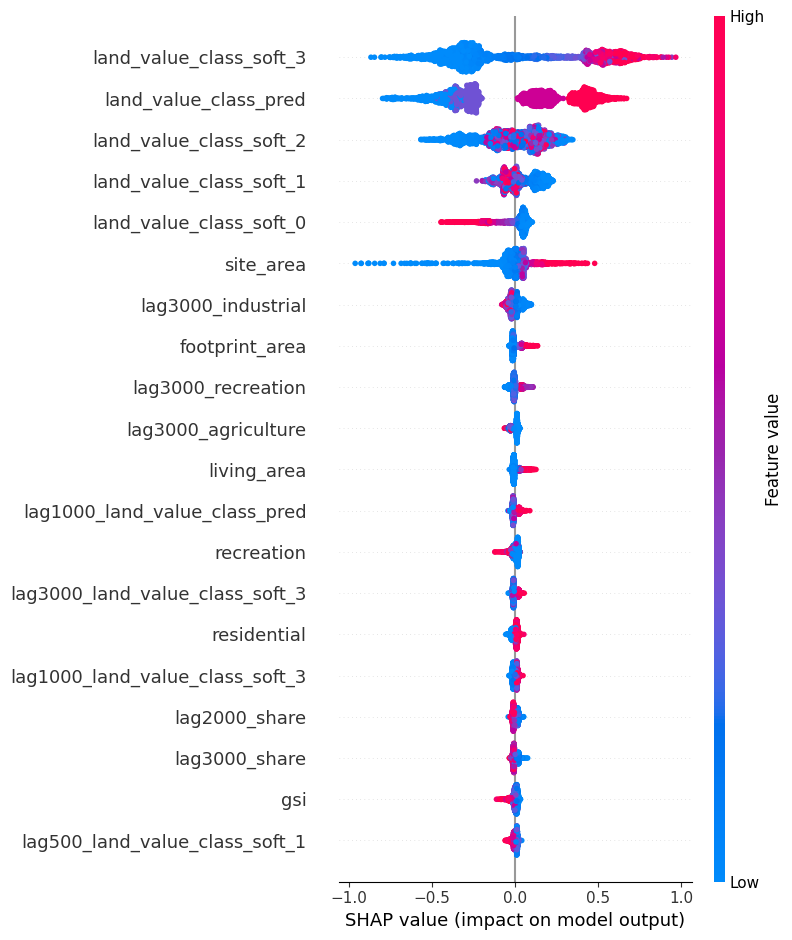

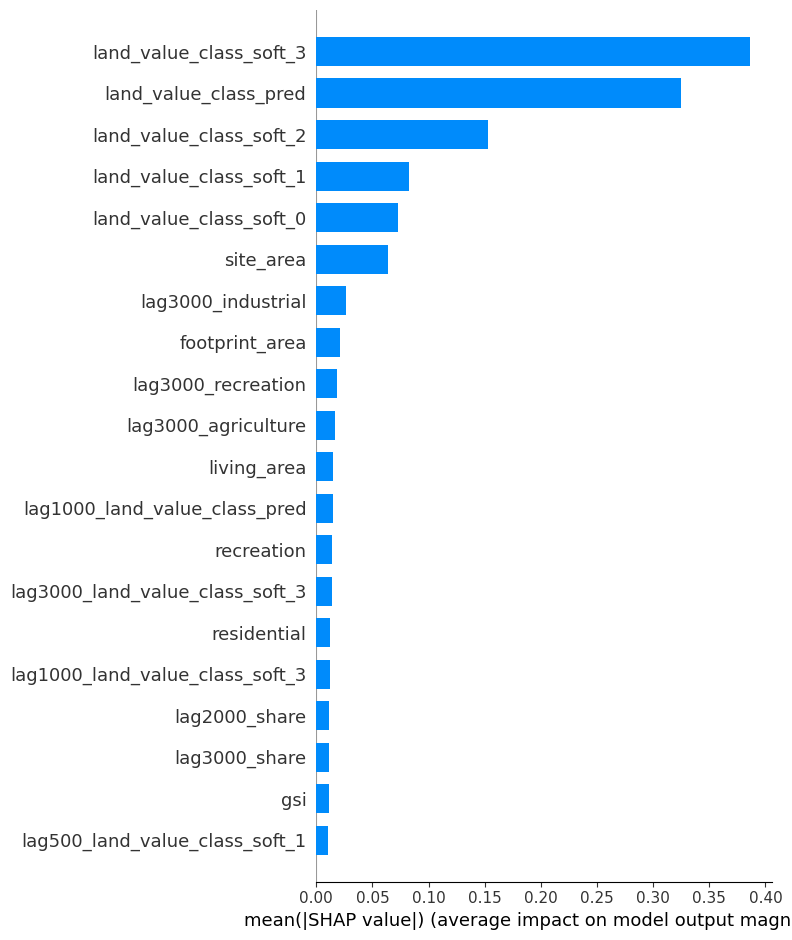

In [31]:
# === SHAP через библиотеку shap: beeswarm + bar для текущей модели ===
import shap
import numpy as np

from urbanomy.methods.land_value_modeling.training_utils import (
    prep_cat_inplace,
    build_radii_weights,
    add_lags_full_df,
    feature_names,
)

# Используем переменные из твоего трейнинга:
# target_col, feature_cols, cat_features, radius_list, blocks_clean, model

numeric_feats = [
    c for c in feature_cols
    if c not in cat_features and c != target_col and c in blocks_clean.columns
]

work_df = blocks_clean.copy()
prep_cat_inplace(work_df, cat_features)

weights_shap = build_radii_weights(work_df, radius_list)
data_lag_shap = add_lags_full_df(work_df, weights=weights_shap, numeric_cols=numeric_feats)

base_cols_for_model = list(dict.fromkeys(list(feature_cols) + list(cat_features)))
feats = feature_names(data_lag_shap, base_cols_for_model, target_col)

X_shap = data_lag_shap[feats].copy()

# Опционально: сэмпл для ускорения
max_rows = 3000
if len(X_shap) > max_rows:
    X_shap = X_shap.sample(max_rows, random_state=42)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# Для совместимости с разными версиями shap/catboost
if isinstance(shap_values, list):
    shap_values = shap_values[0]

# 1) Beeswarm
shap.summary_plot(shap_values, X_shap, feature_names=feats, show=True)

# 2) Bar (mean |SHAP|)
shap.summary_plot(shap_values, X_shap, feature_names=feats, plot_type="bar", show=True)


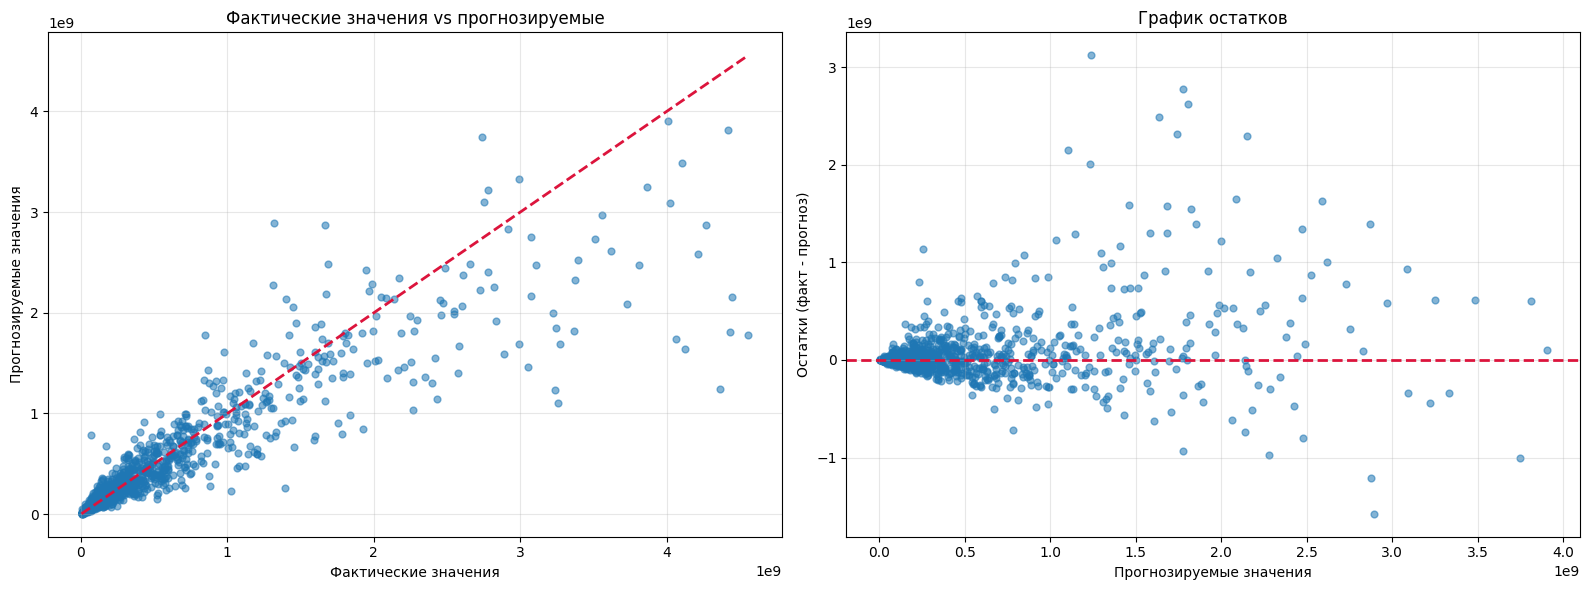

In [25]:
import numpy as np
import matplotlib.pyplot as plt

plot_mask = np.isfinite(y_test_true) & np.isfinite(y_test_pred)
y_true_plot = y_test_true[plot_mask]
y_pred_plot = y_test_pred[plot_mask]
residuals = y_true_plot - y_pred_plot

min_val = min(y_true_plot.min(), y_pred_plot.min())
max_val = max(y_true_plot.max(), y_pred_plot.max())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Разброс фактических значений по сравнению с прогнозируемыми
axes[0].scatter(y_true_plot, y_pred_plot, alpha=0.55, s=24)
axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    color="crimson",
    linestyle="--",
    linewidth=2,
)
axes[0].set_title("Фактические значения vs прогнозируемые")
axes[0].set_xlabel("Фактические значения")
axes[0].set_ylabel("Прогнозируемые значения")
axes[0].grid(alpha=0.3)

# 2. График остатков
axes[1].scatter(y_pred_plot, residuals, alpha=0.55, s=24)
axes[1].axhline(0, color="crimson", linestyle="--", linewidth=2)
axes[1].set_title("График остатков")
axes[1].set_xlabel("Прогнозируемые значения")
axes[1].set_ylabel("Остатки (факт - прогноз)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()



In [24]:
# import re
# import numpy as np
# import pandas as pd
# from catboost import CatBoostRegressor, Pool
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# # 1) Разбиваем фичи на base / lag-группы по радиусам
# lag_groups = {r: [] for r in radius_list}
# other_lag_feats = []
# base_feats = []

# for f in feats:
#     matched = False
#     for r in radius_list:
#         if f.startswith(f"lag{r}_"):
#             lag_groups[r].append(f)
#             matched = True
#             break

#     if matched:
#         continue

#     if f.startswith("lag"):
#         other_lag_feats.append(f)
#     else:
#         base_feats.append(f)

# print("Base feats:", len(base_feats))
# for r in radius_list:
#     print(f"Lag feats radius {r}: {len(lag_groups[r])}")
# print("Other lag feats:", len(other_lag_feats))



# # 2) Универсальная функция оценки
# def evaluate_feature_set(feature_set, name):
#     feature_set = list(dict.fromkeys(feature_set))
#     feature_set = [f for f in feature_set if f in df_train.columns and f in df_test.columns]
#     cat_subset = [c for c in cat_features if c in feature_set]

#     train_pool = Pool(
#         df_train[feature_set],
#         label=df_train[target_col],
#         cat_features=cat_subset,
#         feature_names=feature_set,
#     )
#     test_pool = Pool(
#         df_test[feature_set],
#         label=df_test[target_col],
#         cat_features=cat_subset,
#         feature_names=feature_set,
#     )

#     model = CatBoostRegressor(
#         loss_function="MAE",
#         eval_metric="MAE",
#         iterations=5000,
#         od_type="Iter",
#         od_wait=300,
#         random_seed=seed,
#         verbose=False,
#     )

#     model.fit(
#         train_pool,
#         eval_set=test_pool,
#         early_stopping_rounds=300,
#         use_best_model=True,
#         verbose=False,
#     )

#     y_train_pred_raw = np.asarray(model.predict(df_train[feature_set])).reshape(-1)
#     y_test_pred_raw = np.asarray(model.predict(df_test[feature_set])).reshape(-1)

#     y_train_true_raw = df_train[target_col].to_numpy()
#     y_test_true_raw = df_test[target_col].to_numpy()

#     y_train_true = to_original_scale(y_train_true_raw, target_col=target_col)
#     y_train_pred = to_original_scale(y_train_pred_raw, target_col=target_col)

#     y_test_true = to_original_scale(y_test_true_raw, target_col=target_col)
#     y_test_pred = to_original_scale(y_test_pred_raw, target_col=target_col)

#     return {
#         "set_name": name,
#         "n_features": len(feature_set),
#         "best_iteration": model.get_best_iteration() + 1 if model.get_best_iteration() is not None else None,
#         "train_mape": mape(y_train_true, y_train_pred),
#         "train_wape": wape(y_train_true, y_train_pred),
#         "train_mae": mean_absolute_error(y_train_true, y_train_pred),
#         "train_rmse": np.sqrt(mean_squared_error(y_train_true, y_train_pred)),
#         "train_r2": r2_score(y_train_true, y_train_pred),
#         "test_mape": mape(y_test_true, y_test_pred),
#         "test_wape": wape(y_test_true, y_test_pred),
#         "test_mae": mean_absolute_error(y_test_true, y_test_pred),
#         "test_rmse": np.sqrt(mean_squared_error(y_test_true, y_test_pred)),
#         "test_r2": r2_score(y_test_true, y_test_pred),
#         "features": feature_set,
#         "model": model,
#     }

# # 3) Наборы для ablation
# candidate_sets = {
#     "base_only": base_feats,
# }

# for r in radius_list:
#     candidate_sets[f"base_plus_r{r}"] = base_feats + lag_groups[r]

# cumulative = []
# for r in radius_list:
#     cumulative = cumulative + lag_groups[r]
#     candidate_sets[f"base_plus_to_r{r}"] = base_feats + cumulative

# if len(other_lag_feats) > 0:
#     candidate_sets["base_plus_other_lags"] = base_feats + other_lag_feats
#     candidate_sets["all_features"] = base_feats + cumulative + other_lag_feats
# else:
#     candidate_sets["all_features"] = base_feats + cumulative

# # 4) Прогон
# ablation_results = []
# ablation_models = {}

# for name, feature_set in candidate_sets.items():
#     res = evaluate_feature_set(feature_set, name)
#     ablation_models[name] = res["model"]
#     ablation_results.append({k: v for k, v in res.items() if k not in ["features", "model"]})

# ablation_df = (
#     pd.DataFrame(ablation_results)
#     .sort_values(["test_mae", "test_wape", "test_rmse"], ascending=True)
#     .reset_index(drop=True)
# )

# display(ablation_df)

# best_ablation_name = ablation_df.iloc[0]["set_name"]
# print("Best ablation set:", best_ablation_name)


In [25]:
# # === Simple train/test training with selected features ===
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
# import numpy as np
# from catboost import CatBoostRegressor, Pool
# from urbanomy.methods.land_value_modeling.training_utils import (
#     build_radii_weights,
#     add_lags_full_df,
#     feature_names,
#     to_original_scale,
#     mape,
#     wape,
# )
# selected_features = candidate_sets["base_plus_r3000"]

# # 1) Настройки
# target_col = "land_value_per_sqm"
# radius_list = [300, 500, 1000, 2000, 3000]
# test_size = 0.1
# seed = 42
# use_services = False

# # Сюда можно передать отобранные фичи, например:
# # selected_features = top_60_features
# selected_features = None

# exclude_base = {
#     "geometry",
#     "land_value",
#     "land_value_per_sqm",
#     "log_land_value_per_sqm",
#     "log_land_value",
#     "osr",
#     "share_non_living",
#     "share_living",
#     "land_value_class_soft_expected",
#     "district_name",
# }

# cat_features = [c for c in ["land_use", "morphotype"] if c in blocks_clean.columns]

# def is_service_col(col: str) -> bool:
#     return col.lower().startswith("count_")

# # 2) Базовые признаки
# feature_cols = []
# for c in blocks_clean.columns:
#     if c in exclude_base:
#         continue
#     if (not use_services) and is_service_col(c):
#         continue
#     feature_cols.append(c)

# # 3) Подготовка данных + lag-фичи
# data_df = blocks_clean.copy()

# for c in cat_features:
#     data_df[c] = data_df[c].astype("string").fillna("missing")

# numeric_feats = [
#     c for c in feature_cols
#     if c not in cat_features and c != target_col and c in data_df.columns
# ]

# weights = build_radii_weights(data_df, radius_list)
# data_lag = add_lags_full_df(data_df, weights=weights, numeric_cols=numeric_feats)

# base_cols_for_model = list(dict.fromkeys(
#     [c for c in feature_cols if c in data_lag.columns] + cat_features
# ))
# all_feats = feature_names(data_lag, base_cols_for_model, target_col)

# selected_features = candidate_sets["base_plus_r3000"]

# # 4) Выбор фичей для обучения
# if selected_features is None:
#     feats = all_feats
# else:
#     feats = [f for f in selected_features if f in all_feats]
#     if len(feats) == 0:
#         raise ValueError("selected_features is empty after filtering by available model features")

# cat_features_model = [c for c in cat_features if c in feats]

# print(f"Total available features: {len(all_feats)}")
# print(f"Selected features for training: {len(feats)}")

# # 5) Train/test split
# idx_train, idx_test = train_test_split(
#     data_lag.index,
#     test_size=test_size,
#     random_state=seed,
#     shuffle=True,
# )

# df_train = data_lag.loc[idx_train].copy()
# df_test = data_lag.loc[idx_test].copy()

# train_pool = Pool(
#     df_train[feats],
#     label=df_train[target_col],
#     cat_features=cat_features_model,
#     feature_names=feats,
# )
# test_pool = Pool(
#     df_test[feats],
#     label=df_test[target_col],
#     cat_features=cat_features_model,
#     feature_names=feats,
# )

# # 6) Обучение
# model = CatBoostRegressor(
#     loss_function="MAE",
#     eval_metric="MAE",
#     iterations=20000,
#     od_type="Iter",
#     od_wait=2000,
#     random_seed=seed,
#     verbose=200,
# )

# model.fit(
#     train_pool,
#     eval_set=test_pool,
#     early_stopping_rounds=600,
#     use_best_model=True,
# )

# # 7) Метрики на train/test в оригинальной шкале
# # --- Train ---
# y_train_pred_raw = np.asarray(model.predict(df_train[feats])).reshape(-1)
# y_train_true_raw = df_train[target_col].to_numpy()

# y_train_true = to_original_scale(y_train_true_raw, target_col=target_col)
# y_train_pred = to_original_scale(y_train_pred_raw, target_col=target_col)

# train_mape = mape(y_train_true, y_train_pred)
# train_wape = wape(y_train_true, y_train_pred)
# train_r2 = r2_score(y_train_true, y_train_pred)
# train_mae = mean_absolute_error(y_train_true, y_train_pred)
# train_rmse = np.sqrt(mean_squared_error(y_train_true, y_train_pred))

# # --- Test ---
# y_test_pred_raw = np.asarray(model.predict(df_test[feats])).reshape(-1)
# y_test_true_raw = df_test[target_col].to_numpy()

# y_test_true = to_original_scale(y_test_true_raw, target_col=target_col)
# y_test_pred = to_original_scale(y_test_pred_raw, target_col=target_col)

# test_mape = mape(y_test_true, y_test_pred)
# test_wape = wape(y_test_true, y_test_pred)
# test_r2 = r2_score(y_test_true, y_test_pred)
# test_mae = mean_absolute_error(y_test_true, y_test_pred)
# test_rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))

# print("Train metrics:")
# print(f"MAPE: {train_mape:.6f} ({train_mape*100:.2f}%)")
# print(f"WAPE: {train_wape:.6f} ({train_wape*100:.2f}%)")
# print(f"MAE:  {train_mae:.6f}")
# print(f"RMSE: {train_rmse:.6f}")
# print(f"R2:   {train_r2:.6f}")

# print("\nTest metrics:")
# print(f"MAPE: {test_mape:.6f} ({test_mape*100:.2f}%)")
# print(f"WAPE: {test_wape:.6f} ({test_wape*100:.2f}%)")
# print(f"MAE:  {test_mae:.6f}")
# print(f"RMSE: {test_rmse:.6f}")
# print(f"R2:   {test_r2:.6f}")


In [26]:
# import matplotlib.pyplot as plt
# import numpy as np

# fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=False, sharey=False)

# # Train
# axes[0].scatter(y_train_true, y_train_pred, alpha=0.35, s=20)
# mn = min(y_train_true.min(), y_train_pred.min())
# mx = max(y_train_true.max(), y_train_pred.max())
# axes[0].plot([mn, mx], [mn, mx], "r--", linewidth=2)
# axes[0].set_title("Train: true vs predicted price")
# axes[0].set_xlabel("True price")
# axes[0].set_ylabel("Predicted price")
# axes[0].grid(alpha=0.3)

# # Test
# axes[1].scatter(y_test_true, y_test_pred, alpha=0.35, s=20)
# mn = min(y_test_true.min(), y_test_pred.min())
# mx = max(y_test_true.max(), y_test_pred.max())
# axes[1].plot([mn, mx], [mn, mx], "r--", linewidth=2)
# axes[1].set_title("Test: true vs predicted price")
# axes[1].set_xlabel("True price")
# axes[1].set_ylabel("Predicted price")
# axes[1].grid(alpha=0.3)

# plt.tight_layout()
# plt.show()


# Основное обучение

In [ ]:
from urbanomy.methods.land_value_modeling.training_utils import TrainingConfig, run_training
import logging

use_services = False
target_col = "log_land_value"
radius_list = [500, 1000, 2000, 3000]

exclude_base = {
    "geometry",
    "land_value",
    "land_value_per_sqm",
    "log_land_value_per_sqm",
    "log_land_value",
    "osr",
    "share_non_living",
    "share_living",
    # "land_value_class_soft_0",
    # "land_value_class_soft_1",
    # "land_value_class_soft_2",
    # "land_value_class_soft_3",
    # "land_value_class_soft_4",
    # "land_value_class_pred",
    "land_value_class_soft_expected",
    "district_name",
    "number_of_floors",
}

def is_service_col(col: str) -> bool:
    return col.lower().startswith("count_")

feature_cols = []
for c in blocks.columns:
    if c in exclude_base:
        continue
    if (not use_services) and is_service_col(c):
        continue
    feature_cols.append(c)

cat_features = ["land_use", "morphotype", "land_value_class_pred"]

cfg = TrainingConfig(
    feature_cols=feature_cols,
    cat_features=cat_features,
    radius_list=radius_list,
    target_col=target_col,
    group_col="district_name",
    loss_function="MAE",
    eval_metric="MAE",
    iterations=20000,
    od_wait=2000,
    seed=42,
    params={
        "depth": 6,
        "learning_rate": 0.03,
        "l2_leaf_reg": 3,
        "random_strength": 1.0,
        "bagging_temperature": 1.0,
    },
)

model, metrics = run_training(
    blocks_clean,
    cfg,
    log_path=f"catboost_info/training_{'with_services' if use_services else 'no_services'}.log",
    console_level=logging.WARNING,
)

print("use_services =", use_services)
print("n_folds =", metrics["n_folds"])  # = число районов



[run_training] leave-one-group-out by 'district_name', folds=18


DistrictCV:   0%|          | 0/18 [00:00<?, ?it/s]

0:	learn: 1.0915855	total: 4.92ms	remaining: 18.3s
200:	learn: 0.3258831	total: 948ms	remaining: 16.6s
400:	learn: 0.2839720	total: 1.89s	remaining: 15.6s
600:	learn: 0.2562251	total: 2.82s	remaining: 14.6s
800:	learn: 0.2377617	total: 3.75s	remaining: 13.6s
1000:	learn: 0.2230739	total: 4.67s	remaining: 12.7s
1200:	learn: 0.2117462	total: 5.62s	remaining: 11.7s
1400:	learn: 0.2021790	total: 6.56s	remaining: 10.8s
1600:	learn: 0.1938584	total: 7.51s	remaining: 9.9s
1800:	learn: 0.1867460	total: 8.44s	remaining: 8.96s
2000:	learn: 0.1804694	total: 9.37s	remaining: 8.02s
2200:	learn: 0.1750002	total: 10.3s	remaining: 7.07s
2400:	learn: 0.1699601	total: 11.2s	remaining: 6.11s
2600:	learn: 0.1654687	total: 12.1s	remaining: 5.18s
2800:	learn: 0.1614020	total: 13.1s	remaining: 4.25s
3000:	learn: 0.1575465	total: 14s	remaining: 3.32s
3200:	learn: 0.1539827	total: 14.9s	remaining: 2.39s
3400:	learn: 0.1509665	total: 15.9s	remaining: 1.46s
3600:	learn: 0.1479588	total: 16.8s	remaining: 523ms
37

In [22]:
district_counts = (
    blocks_clean
    .assign(district_name=blocks_clean["district_name"].astype("string").fillna("missing"))
    .groupby("district_name", dropna=False)
    .size()
    .reset_index(name="n_blocks")
    .sort_values("n_blocks", ascending=False)
)

display(district_counts)


,district_name,n_blocks
9,Курортный район,968
15,Пушкинский район,837
7,Красносельский район,775
14,Приморский район,588
13,Петродворцовый район,556
2,Выборгский район,521
5,Колпинский район,315
10,Московский район,293
11,Невский район,287
6,Красногвардейский район,282


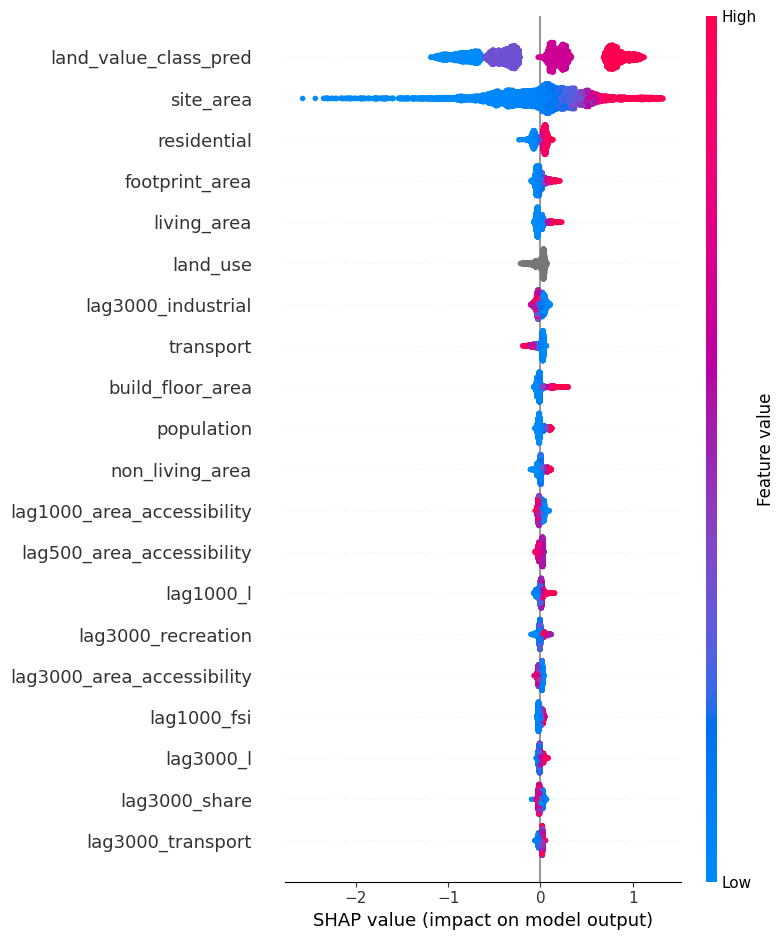

In [24]:
# === SHAP: beeswarm + bar для текущей модели ===
import shap

from urbanomy.methods.land_value_modeling.training_utils import (
    prep_cat_inplace,
    build_radii_weights,
    add_lags_full_df,
    feature_names,
)

target_col = cfg.target_col

numeric_feats = [
    c for c in cfg.feature_cols
    if c not in cfg.cat_features and c != target_col and c in blocks_clean.columns
]

work_df = blocks_clean.copy()
prep_cat_inplace(work_df, cfg.cat_features)

weights_shap = build_radii_weights(work_df, cfg.radius_list)
data_lag_shap = add_lags_full_df(work_df, weights=weights_shap, numeric_cols=numeric_feats)

base_cols_for_model = list(dict.fromkeys(list(cfg.feature_cols) + list(cfg.cat_features)))
feats = feature_names(data_lag_shap, base_cols_for_model, target_col)

X_shap = data_lag_shap[feats]

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# 1) Beeswarm
shap.summary_plot(shap_values, X_shap, feature_names=feats, show=True)



In [25]:
# === Inference + метрики для текущей модели ===
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error

from urbanomy.methods.land_value_modeling.training_utils import (
    prep_cat_inplace,
    build_radii_weights,
    add_lags_full_df,
    feature_names,
    to_original_scale,
    mape,
    wape,
    rmse,
)

target_col = cfg.target_col

# 1) Восстанавливаем тот же набор числовых фич, что использовался при обучении
numeric_feats = [
    c for c in cfg.feature_cols
    if c not in cfg.cat_features and c != target_col and c in blocks_clean.columns
]

# 2) Готовим данные и считаем лаги так же, как в run_training
work_df = blocks_clean.copy()
prep_cat_inplace(work_df, cfg.cat_features)

weights_inf = build_radii_weights(work_df, cfg.radius_list)
data_lag_inf = add_lags_full_df(work_df, weights=weights_inf, numeric_cols=numeric_feats)

base_cols_for_model = list(dict.fromkeys(list(cfg.feature_cols) + list(cfg.cat_features)))
feats = feature_names(data_lag_inf, base_cols_for_model, target_col)

# 3) Проверка фичей
missing_feats = [c for c in feats if c not in data_lag_inf.columns]
if missing_feats:
    raise ValueError(
        f"Не хватает фичей для модели ({len(missing_feats)}): "
        f"{missing_feats[:20]}{' ...' if len(missing_feats) > 20 else ''}"
    )

# 4) Предсказание
y_pred_raw = np.asarray(model.predict(data_lag_inf[feats])).reshape(-1)
y_pred = to_original_scale(y_pred_raw, target_col=target_col)

out_df = data_lag_inf.copy()
out_df["pred_raw"] = y_pred_raw
out_df[f"{target_col}_pred"] = y_pred

# 5) Метрики
if target_col in out_df.columns:
    y_true_raw = out_df[target_col].to_numpy()
    y_true = to_original_scale(y_true_raw, target_col=target_col)

    out_df[f"{target_col}_true"] = y_true

    mask = np.isfinite(y_true) & np.isfinite(y_pred) & (np.abs(y_true) > 0)

    out_df["error_pct"] = np.nan
    out_df.loc[mask, "error_pct"] = (
        np.abs(y_pred[mask] - y_true[mask]) / np.abs(y_true[mask]) * 100.0
    )

    mape_val = mape(y_true[mask], y_pred[mask])
    wape_val = wape(y_true[mask], y_pred[mask])
    mae_val = mean_absolute_error(y_true[mask], y_pred[mask])
    rmse_val = rmse(y_true[mask], y_pred[mask])
    r2_val = r2_score(y_true[mask], y_pred[mask])

    print(f"Rows used in metrics: {mask.sum()} / {len(mask)}")
    print(f"MAPE: {mape_val:.6f} ({mape_val*100:.2f}%)")
    print(f"WAPE: {wape_val:.6f} ({wape_val*100:.2f}%)")
    print(f"MAE:  {mae_val:.6f}")
    print(f"RMSE: {rmse_val:.6f}")
    print(f"R2:   {r2_val:.6f}")

    display(out_df[[target_col, f"{target_col}_pred", "error_pct"]].head(20))

    out_df_over_10 = out_df[out_df["error_pct"] > 10].copy()
else:
    print(f"Column '{target_col}' not found -> predictions only.")
    display(out_df[[f"{target_col}_pred"]].head(20))


Rows used in metrics: 6946 / 6946
MAPE: 0.148684 (14.87%)
WAPE: 0.136208 (13.62%)
MAE:  66166462.552552
RMSE: 179173403.649079
R2:   0.937414


,log_land_value,log_land_value_pred,error_pct
0,18.676889,1.295127e+08,0.240333
1,19.040968,2.121075e+08,14.069301
2,19.061421,2.017796e+08,6.318119
3,19.737919,3.679253e+08,1.442332
4,17.843517,4.081300e+07,27.312853
5,17.253942,3.090361e+07,0.753006
8,18.918826,2.135351e+08,29.755953
9,19.045901,1.996972e+08,6.866662
10,18.207065,8.586159e+07,6.309268
11,19.935478,3.693170e+08,18.804635


In [26]:
stats_by_landuse = (
    out_df
    .groupby("land_use", dropna=False)
    .agg(
        n=("error_pct", "size"),
        mean_error_pct=("error_pct", "mean"),
        median_error_pct=("error_pct", "median"),
        max_error_pct=("error_pct", "max"),
    )
    .sort_values("mean_error_pct", ascending=False)
)

display(stats_by_landuse)

,n,mean_error_pct,median_error_pct,max_error_pct
land_use,,,,
RECREATION,1054,20.202909,10.471976,454.779835
BUSINESS,270,16.094951,6.185630,562.951423
TRANSPORT,806,15.761708,6.636833,371.377953
RESIDENTIAL,4150,13.954994,7.867817,141.373696
INDUSTRIAL,445,11.973741,4.599713,136.284446
AGRICULTURE,119,8.283828,3.672979,45.162997
SPECIAL,102,6.916634,2.085817,39.069351


In [33]:
out_df_over_100 = out_df[out_df["error_pct"] > 100]
out_df_100 = out_df[out_df["error_pct"] <= 100]

stats_by_landuse = (
    out_df_over_100
    .groupby("land_use", dropna=False)
    .agg(
        n=("error_pct", "size"),
        mean_error_pct=("error_pct", "mean"),
        median_error_pct=("error_pct", "median"),
        max_error_pct=("error_pct", "max"),
    )
)


stats_by_landuse = stats_by_landuse.sort_values("mean_error_pct", ascending=False)

display(stats_by_landuse)


,n,mean_error_pct,median_error_pct,max_error_pct
land_use,,,,
BUSINESS,2,344.102697,344.102697,562.951423
TRANSPORT,8,203.704002,169.061055,371.377953
RECREATION,18,179.850754,146.805952,454.779835
INDUSTRIAL,1,136.284446,136.284446,136.284446
RESIDENTIAL,7,122.726945,124.494716,141.373696


In [46]:
out_df_over_100 = out_df[out_df["error_pct"] > 100]
out_df_100 = out_df[out_df["error_pct"] <= 100]

stats_by_landuse = (
    out_df_100
    .groupby("land_use", dropna=False)
    .agg(
        n=("error_pct", "size"),
        mean_error_pct=("error_pct", "mean"),
        median_error_pct=("error_pct", "median"),
        max_error_pct=("error_pct", "max"),
    )
)


stats_by_landuse = stats_by_landuse.sort_values("mean_error_pct", ascending=False)
display(stats_by_landuse)


,n,mean_error_pct,median_error_pct,max_error_pct
land_use,,,,
RECREATION,1036,17.429105,10.098593,98.254195
TRANSPORT,798,13.877574,6.521810,98.556563
RESIDENTIAL,4143,13.771213,7.832497,98.124814
BUSINESS,268,13.647132,6.151517,97.181137
INDUSTRIAL,444,11.693762,4.551926,87.454901
AGRICULTURE,119,8.283828,3.672979,45.162997
SPECIAL,102,6.916634,2.085817,39.069351


In [ ]:
import numpy as np
import pandas as pd

pred_col = "land_value_pred"   # или f"{target_col}_pred".replace("log_", "")
group_col = "land_use"
alpha = 0.05
n_boot = 5000
seed = 42

df_ci = out_df.copy()

if pred_col not in df_ci.columns:
    fallback_col = f"{target_col}_pred"
    if fallback_col in df_ci.columns:
        pred_col = fallback_col
    else:
        raise KeyError(f"Column '{pred_col}' not found in out_df")

df_ci[pred_col] = pd.to_numeric(df_ci[pred_col], errors="coerce")
df_ci = df_ci.loc[np.isfinite(df_ci[pred_col])].copy()

if df_ci.empty:
    raise ValueError("No valid predictions found")

rng = np.random.default_rng(seed)

def bootstrap_mean_ci(values: np.ndarray, alpha: float = 0.05, n_boot: int = 5000):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan, np.nan

    boot_means = np.empty(n_boot, dtype=float)
    n = len(values)

    for i in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        boot_means[i] = sample.mean()

    mean_val = float(values.mean())
    lower = float(np.quantile(boot_means, alpha / 2))
    upper = float(np.quantile(boot_means, 1 - alpha / 2))
    return mean_val, lower, upper

# Общий интервал
mean_pred, ci_lower, ci_upper = bootstrap_mean_ci(
    df_ci[pred_col].to_numpy(),
    alpha=alpha,
    n_boot=n_boot,
)

print(f"Mean predicted land value: {mean_pred:,.2f}")
print(f"95% confidence interval for mean predicted land value: [{ci_lower:,.2f}, {ci_upper:,.2f}]")

# По land_use
ci_by_landuse = (
    df_ci.groupby(group_col, dropna=False)[pred_col]
    .apply(lambda s: pd.Series(
        bootstrap_mean_ci(s.to_numpy(), alpha=alpha, n_boot=n_boot),
        index=["mean_pred", "ci_lower", "ci_upper"]
    ))
    .unstack()
)

ci_by_landuse["ci_width"] = ci_by_landuse["ci_upper"] - ci_by_landuse["ci_lower"]

with pd.option_context("display.float_format", "{:,.2f}".format):
    display(ci_by_landuse.sort_values("mean_pred", ascending=False))


Mean predicted land value: 457,836,958.16
95% confidence interval for mean predicted land value: [438,408,604.99, 477,812,691.44]


,mean_pred,ci_lower,ci_upper,ci_width
land_use,,,,
INDUSTRIAL,"653,834,039.10","577,272,005.73","736,999,740.43","159,727,734.70"
RESIDENTIAL,"503,939,909.03","475,834,862.86","533,452,331.23","57,617,468.37"
AGRICULTURE,"429,263,899.43","326,814,826.57","549,860,505.57","223,045,679.00"
RECREATION,"424,894,123.62","381,424,011.81","472,760,295.77","91,336,283.96"
SPECIAL,"379,202,847.34","282,259,936.06","486,281,630.33","204,021,694.27"
BUSINESS,"337,022,860.09","280,996,400.33","397,836,702.72","116,840,302.39"
TRANSPORT,"209,966,586.23","184,246,965.31","238,173,934.05","53,926,968.74"


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pred_col = "land_value_pred"
n_boot = 3000
alpha = 0.05
seed = 42

df_boot = out_df.copy()

if pred_col not in df_boot.columns:
    fallback_col = f"{target_col}_pred".replace("log_", "")
    if fallback_col in df_boot.columns:
        pred_col = fallback_col
    else:
        raise KeyError(f"Column '{pred_col}' not found in out_df")

values = pd.to_numeric(df_boot[pred_col], errors="coerce").dropna().to_numpy()

if len(values) == 0:
    raise ValueError("No valid predicted values found")

rng = np.random.default_rng(seed)
boot_means = np.empty(n_boot, dtype=float)

n = len(values)
for i in range(n_boot):
    sample = rng.choice(values, size=n, replace=True)
    boot_means[i] = sample.mean()

mean_pred = values.mean()
ci_lower = np.quantile(boot_means, alpha / 2)
ci_upper = np.quantile(boot_means, 1 - alpha / 2)

print(f"Mean predicted land value: {mean_pred:,.2f}")
print(f"95% bootstrap CI for mean predicted land value: [{ci_lower:,.2f}, {ci_upper:,.2f}]")

plt.figure(figsize=(10, 6))
plt.hist(boot_means, bins=40, color="steelblue", alpha=0.8, edgecolor="white")
plt.axvline(mean_pred, color="black", linestyle="--", linewidth=2, label=f"Mean = {mean_pred:,.0f}")
plt.axvline(ci_lower, color="crimson", linestyle="--", linewidth=2, label=f"2.5% = {ci_lower:,.0f}")
plt.axvline(ci_upper, color="crimson", linestyle="--", linewidth=2, label=f"97.5% = {ci_upper:,.0f}")

plt.title("Bootstrap distribution of mean predicted land value")
plt.xlabel("Mean predicted land value")
plt.ylabel("Frequency")
plt.legend()
plt.ticklabel_format(style="plain", axis="x")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


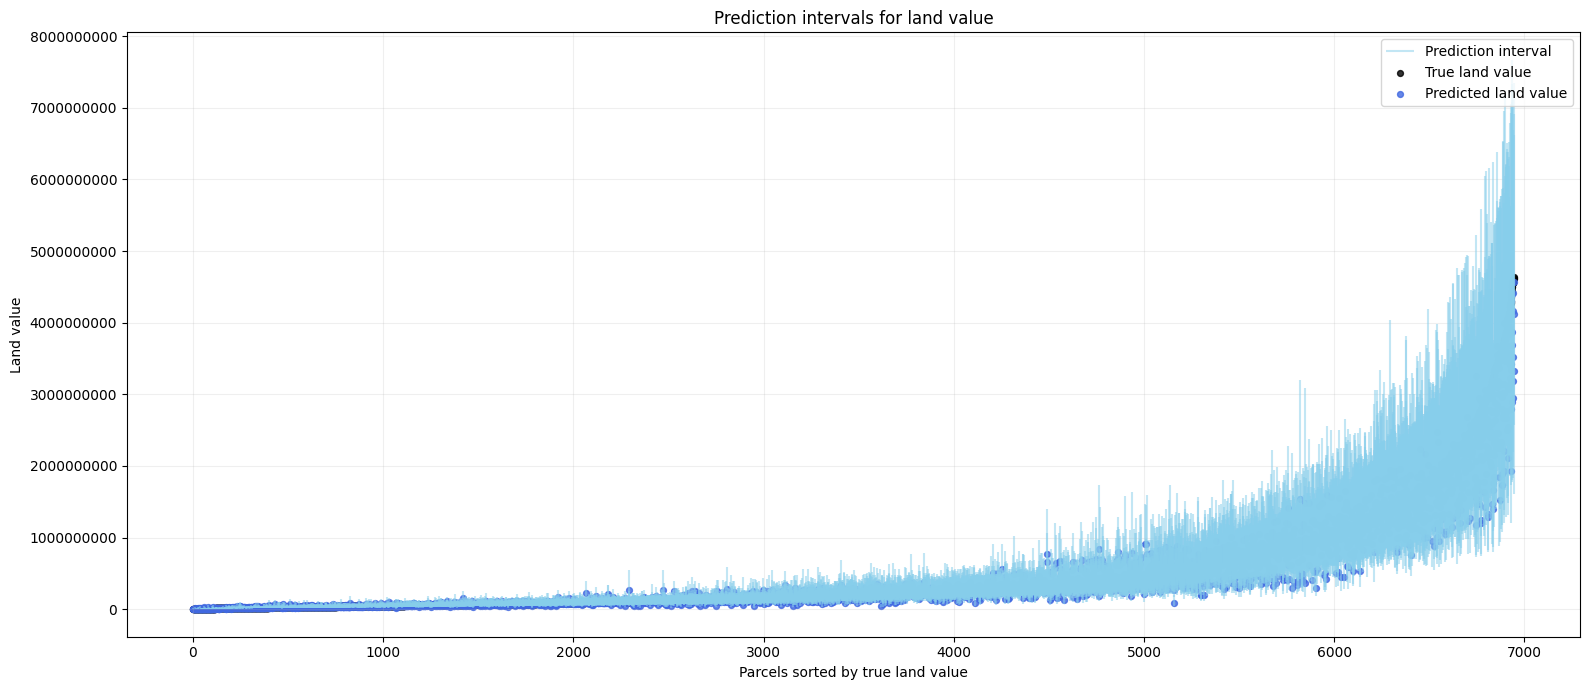

In [69]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

true_col = "land_value_true"
pred_col = "land_value_pred"

plot_df = out_df.copy()

required_cols = [true_col, pred_col, "pi_lower", "pi_upper"]
missing_cols = [c for c in required_cols if c not in plot_df.columns]
if missing_cols:
    raise KeyError(f"Missing columns in out_df: {missing_cols}")

valid_mask = (
    np.isfinite(plot_df[true_col].to_numpy()) &
    np.isfinite(plot_df[pred_col].to_numpy()) &
    np.isfinite(plot_df["pi_lower"].to_numpy()) &
    np.isfinite(plot_df["pi_upper"].to_numpy())
)
plot_df = plot_df.loc[valid_mask].copy()

# сортируем по истинной стоимости, чтобы график читался
plot_df = plot_df.sort_values(true_col).reset_index(drop=True)

x = np.arange(len(plot_df))
y_true = plot_df[true_col].to_numpy()
y_pred = plot_df[pred_col].to_numpy()
y_lower = plot_df["pi_lower"].to_numpy()
y_upper = plot_df["pi_upper"].to_numpy()

plt.figure(figsize=(16, 7))

plt.vlines(
    x,
    y_lower,
    y_upper,
    color="skyblue",
    alpha=0.5,
    linewidth=1.5,
    label="Prediction interval",
)

plt.scatter(
    x,
    y_true,
    s=18,
    color="black",
    alpha=0.8,
    label="True land value",
)

plt.scatter(
    x,
    y_pred,
    s=18,
    color="royalblue",
    alpha=0.8,
    label="Predicted land value",
)

plt.title("Prediction intervals for land value")
plt.xlabel("Parcels sorted by true land value")
plt.ylabel("Land value")
plt.legend()
plt.grid(alpha=0.2)
plt.ticklabel_format(style="plain", axis="y")
plt.tight_layout()
plt.show()


In [62]:
import numpy as np
import pandas as pd

true_col = "land_value_true"
pred_col = "land_value_pred"
tol = 0.05  # +/- 5%

df_eval = out_df.copy()

valid_mask = (
    np.isfinite(df_eval[true_col].to_numpy()) &
    np.isfinite(df_eval[pred_col].to_numpy())
)
df_eval = df_eval.loc[valid_mask].copy()

df_eval["lower_5pct"] = df_eval[true_col] * (1 - tol)
df_eval["upper_5pct"] = df_eval[true_col] * (1 + tol)

df_eval["pred_in_5pct_band"] = (
    (df_eval[pred_col] >= df_eval["lower_5pct"]) &
    (df_eval[pred_col] <= df_eval["upper_5pct"])
)

hit_rate_pct = df_eval["pred_in_5pct_band"].mean() * 100

print(f"Share of predictions within +/-5% of true land value: {hit_rate_pct:.2f}%")

display(
    df_eval[
        [
            "land_use",
            true_col,
            pred_col,
            "lower_5pct",
            "upper_5pct",
            "pred_in_5pct_band",
        ]
    ].head(20)
)


Share of predictions within +/-5% of true land value: 41.38%


,land_use,land_value_true,land_value_pred,lower_5pct,upper_5pct,pred_in_5pct_band
0,AGRICULTURE,"129,202,173.99","129,512,688.81","122,742,065.29","135,662,282.69",True
1,RESIDENTIAL,"185,946,167.88","212,107,494.57","176,648,859.49","195,243,476.28",False
2,RESIDENTIAL,"189,788,550.29","201,779,617.22","180,299,122.78","199,277,977.81",False
3,RESIDENTIAL,"373,309,691.92","367,925,326.04","354,644,207.32","391,975,176.52",True
4,INDUSTRIAL,"56,148,855.34","40,813,001.01","53,341,412.57","58,956,298.10",False
5,AGRICULTURE,"31,138,079.66","30,903,607.97","29,581,175.67","32,694,983.64",True
8,RESIDENTIAL,"164,566,674.04","213,535,056.32","156,338,340.34","172,795,007.74",False
9,RESIDENTIAL,"186,865,799.42","199,697,242.52","177,522,509.45","196,209,089.39",False
10,RESIDENTIAL,"80,765,856.62","85,861,591.06","76,727,563.79","84,804,149.46",False
11,AGRICULTURE,"454,849,875.53","369,317,018.16","432,107,381.76","477,592,369.31",False


In [ ]:
# model_path = f"catboost_land_value_{'with_services' if use_services else 'no_services'}.cbm"
# model.save_model(model_path)
# print(model_path)

